# Probability
## Definitions & Bayes Theory

> **Disclaimer:** This notebook was generated with the assistance of AI and has been human-reviewed for accuracy and quality.

**Topics Covered:**
- Elementary Events  
- Non-Elementary Events
- Law of Large Numbers
- Bayesian Statistics

## Big O Warmup

Evaluate the following codeblocks and determine their Big O Notation.

In [88]:
def evaluate(obj) -> float:
    total = 0
    for r in obj:
        val = r.strip()
        total = total + float(val)

    return total

obj = open("data.txt")
print(evaluate(obj))

886.7


In [89]:
def evaluate(obj) -> int:
    total = 0
    for r in obj:
        total += r

    return total // len(obj)

obj = [2, 4, 10, 12, 5, 8, 9]
print(evaluate(obj))

7


## 1. Introduction to Probability

Probability is the study of how likely an event is to occur. It is expressed as a number between **0** (impossible) and **1** (certain).

---

### Elementary Event
An **elementary event** is the simplest possible outcome of a random experiment — a single, indivisible result. It cannot be broken down into smaller outcomes.

- Flipping a coin and getting **Heads** is an elementary event.
- Rolling a die and getting **4** is an elementary event.

---

### Non-Elementary Event
A **non-elementary event** (also called a *compound event*) is any outcome made up of **two or more elementary events** combined.

- Rolling a die and getting an **even number** is a non-elementary event — it includes the outcomes {2, 4, 6}.
- Drawing a **face card** from a deck is non-elementary — it includes Jacks, Queens, and Kings across all suits.

---

### Frequentist Statistics
**Frequentist statistics** defines probability based on **long-run frequency** — how often an event occurs over a large number of repeated trials. If you flip a fair coin 10,000 times, it will land Heads close to 50% of the time. Probability is treated as a fixed, objective fact about the world.

---

### Bayesian Statistics
**Bayesian statistics** defines probability as a **degree of belief** that is updated as new evidence is collected. You start with a prior belief (e.g., "I think this coin is fair"), observe data, and update your belief accordingly. Probability is treated as subjective and dynamic.

---

For each of the elementary events below, what is the probability of the result we randomly pull?

In [90]:
import random

# --- Coin Flip ---
# Elementary events: Heads, Tails
coin_outcomes = ["Heads", "Tails"]

coin_result = random.choice(coin_outcomes)

print("Coin flip sample space: ", coin_outcomes)
print("Result: ", coin_result)

Coin flip sample space:  ['Heads', 'Tails']
Result:  Heads


In [91]:
# --- Dice Roll ---
# Elementary events: 1, 2, 3, 4, 5, 6
dice_outcomes = [1, 2, 3, 4, 5, 6]

dice_result = random.choice(dice_outcomes)

print("Dice roll sample space: ", dice_outcomes)
print("Result: ", dice_result)

Dice roll sample space:  [1, 2, 3, 4, 5, 6]
Result:  1


In [120]:
# --- Drawing a Card ---
# Elementary events: each individual card in a standard 52-card deck
ranks = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "Jack", "Queen", "King", "Ace"]
suits = ["Hearts", "Diamonds", "Clubs", "Spades"]
deck = []

for rank in ranks:
    for suit in suits:
        deck.append(rank + " of " + suit)

card_result = random.choice(deck)

print(deck)

['2 of Hearts', '2 of Diamonds', '2 of Clubs', '2 of Spades', '3 of Hearts', '3 of Diamonds', '3 of Clubs', '3 of Spades', '4 of Hearts', '4 of Diamonds', '4 of Clubs', '4 of Spades', '5 of Hearts', '5 of Diamonds', '5 of Clubs', '5 of Spades', '6 of Hearts', '6 of Diamonds', '6 of Clubs', '6 of Spades', '7 of Hearts', '7 of Diamonds', '7 of Clubs', '7 of Spades', '8 of Hearts', '8 of Diamonds', '8 of Clubs', '8 of Spades', '9 of Hearts', '9 of Diamonds', '9 of Clubs', '9 of Spades', '10 of Hearts', '10 of Diamonds', '10 of Clubs', '10 of Spades', 'Jack of Hearts', 'Jack of Diamonds', 'Jack of Clubs', 'Jack of Spades', 'Queen of Hearts', 'Queen of Diamonds', 'Queen of Clubs', 'Queen of Spades', 'King of Hearts', 'King of Diamonds', 'King of Clubs', 'King of Spades', 'Ace of Hearts', 'Ace of Diamonds', 'Ace of Clubs', 'Ace of Spades']


In [121]:
print("Deck size: ", len(deck), " cards")
print("Result: ", card_result)

Deck size:  52  cards
Result:  7 of Spades


In [140]:
# --- Drawing a Marble from a Bag ---
# Elementary events: each individual marble by color
marble_bag = ["Red", "Red", "Blue", "Blue", "Blue", "Green", "Yellow"]

marble_result = random.choice(marble_bag)

print("Marble bag: ", str(marble_bag))
print("Result: ", marble_result, " marble")

Marble bag:  ['Red', 'Red', 'Blue', 'Blue', 'Blue', 'Green', 'Yellow']
Result:  Blue  marble


## 2a. Non-Elementary Events

A **non-elementary event** is any event that is built from combining two or more elementary events. Instead of asking "what is the probability of this one outcome?", we ask questions like "what is the probability of this *or* that?" or "what is the probability of *not* this?"

We use three core operations to build these compound events:

---

### Mutual Exclusivity
Two events are **mutually exclusive** if they **cannot both occur at the same time**. Knowing one happened tells you the other definitely did not.

$$P(A \cap B) = 0$$

> Example: A single household cannot own both a dog and a cat *under our model* — they own exactly one pet, or none.

**Note:** In the pet ownership distribution below, we assume each household owns at most one pet. This makes all events mutually exclusive. This is a simplification — in reality, households often own more than one pet.

---

### Negation (NOT)
The negation of event A is everything that is **not** A. If you know the probability of A, the probability of it *not* happening is whatever is left over.

$$P(\neg A) = 1 - P(A)$$

> Example: If P(dog) = 0.5, then P(NOT dog) = 1 - 0.5 = 0.5

---

### Intersection (AND)
The intersection is the probability that **both** A and B occur. Because our events are mutually exclusive, this is always zero — a household cannot own two different pets under our model.

$$P(A \cap B) = 0 \quad \text{(mutually exclusive events)}$$

> Example: P(dog AND cat) = 0

---

### Union (OR)
The union is the probability that **at least one** of A or B occurs. For mutually exclusive events, the AND term drops out entirely, so we simply add.

$$P(A \cup B) = P(A) + P(B) \quad \text{(mutually exclusive events)}$$

> Example: P(dog OR cat) = 0.5 + 0.3 = 0.8

---


In [95]:
# Probability distribution: household pet ownership
# Assumption: each household owns at most one pet — all events are mutually exclusive
pet_probs = {
    "dog":     0.5,
    "cat":     0.3,
    "hamster": 0.1,
    "lizard":  0.0,
    "no pet":  0.1
}

p_dog     = pet_probs["dog"]
p_cat     = pet_probs["cat"]
p_hamster = pet_probs["hamster"]
p_lizard  = pet_probs["lizard"]
p_no_pet  = pet_probs["no pet"]

print("=== Pet Ownership Probabilities ===")
print("P(dog)     =", p_dog)
print("P(cat)     =", p_cat)
print("P(hamster) =", p_hamster)
print("P(lizard)  =", p_lizard)
print("P(no pet)  =", p_no_pet)

=== Pet Ownership Probabilities ===
P(dog)     = 0.5
P(cat)     = 0.3
P(hamster) = 0.1
P(lizard)  = 0.0
P(no pet)  = 0.1


In [96]:
# --- NEGATION (NOT) ---
# P(NOT A) = 1 - P(A)
p_not_dog     = 1 - p_dog
p_not_cat     = 1 - p_cat
p_not_hamster = 1 - p_hamster
p_not_lizard  = 1 - p_lizard

print("=== Negation ===")
print("P(NOT dog)     =", p_not_dog)
print("P(NOT cat)     =", p_not_cat)
print("P(NOT hamster) =", p_not_hamster)
print("P(NOT lizard)  =", p_not_lizard)

=== Negation ===
P(NOT dog)     = 0.5
P(NOT cat)     = 0.7
P(NOT hamster) = 0.9
P(NOT lizard)  = 1.0


In [97]:
# --- AND (Intersection) ---
# P(A AND B) = P(A) * P(B)  — valid because events are independent
p_dog_and_cat     = 0
p_dog_and_hamster = 0
p_cat_and_hamster = 0
p_dog_and_lizard  = 0

print("=== AND (Intersection) ===")
print("P(dog AND cat)     =", p_dog_and_cat)
print("P(dog AND hamster) =", p_dog_and_hamster)
print("P(cat AND hamster) =", p_cat_and_hamster)
print("P(dog AND lizard)  =", p_dog_and_lizard)

=== AND (Intersection) ===
P(dog AND cat)     = 0
P(dog AND hamster) = 0
P(cat AND hamster) = 0
P(dog AND lizard)  = 0


In [98]:
# --- OR (Union) ---
# P(A OR B) = P(A) + P(B) - P(A AND B)
p_dog_or_cat     = p_dog + p_cat - p_dog_and_cat
p_dog_or_hamster = p_dog + p_hamster - p_dog_and_hamster
p_cat_or_hamster = p_cat + p_hamster - p_cat_and_hamster
p_dog_or_lizard  = p_dog + p_lizard - p_dog_and_lizard

print("=== OR (Union) ===")
print("P(dog OR cat)     =", p_dog_or_cat)
print("P(dog OR hamster) =", p_dog_or_hamster)
print("P(cat OR hamster) =", p_cat_or_hamster)
print("P(dog OR lizard)  =", p_dog_or_lizard)

=== OR (Union) ===
P(dog OR cat)     = 0.8
P(dog OR hamster) = 0.6
P(cat OR hamster) = 0.4
P(dog OR lizard)  = 0.5


## 2b. Non-Mutually Exclusive Events

Two events are **non-mutually exclusive** if they **can occur at the same time**. Unlike mutually exclusive events, there is an overlap — both A and B can be true simultaneously.

This overlap is called the **intersection**, and we must account for it to avoid double-counting.

---

### AND (Intersection)
When events are non-mutually exclusive and **independent**, the probability that both occur is the product of their individual probabilities.

$$P(A \cap B) = P(A) \times P(B)$$

> Example: P(owns laptop AND took coding course) = 0.85 × 0.60 = 0.51

---

### OR (Union)
Because the events can overlap, simply adding their probabilities would count the overlap twice. We subtract the intersection to correct for this.

$$P(A \cup B) = P(A) + P(B) - P(A \cap B)$$

> Example: P(owns laptop OR took coding course) = 0.85 + 0.60 - 0.51 = 0.94

---

### Negation (NOT)
Negation works the same way regardless of mutual exclusivity.

$$P(\neg A) = 1 - P(A)$$

---

**Distribution below:** A survey of students describing independent characteristics. A student can satisfy any combination of these traits at the same time, making all events non-mutually exclusive.


In [141]:
# Probability distribution: student survey characteristics
# These events are non-mutually exclusive — a student can have any combination of traits
student_probs = {
    "owns_laptop":       0.85,
    "took_coding_course": 0.60,
    "has_part_time_job": 0.35,
    "uses_public_transit": 0.55,
    "exercises_regularly": 0.45
}

p_laptop   = student_probs["owns_laptop"]
p_coding   = student_probs["took_coding_course"]
p_job      = student_probs["has_part_time_job"]
p_transit  = student_probs["uses_public_transit"]
p_exercise = student_probs["exercises_regularly"]

print("=== Student Survey Probabilities ===")
print("P(owns laptop)         =", p_laptop)
print("P(took coding course)  =", p_coding)
print("P(has part-time job)   =", p_job)
print("P(uses public transit) =", p_transit)
print("P(exercises regularly) =", p_exercise)

=== Student Survey Probabilities ===
P(owns laptop)         = 0.85
P(took coding course)  = 0.6
P(has part-time job)   = 0.35
P(uses public transit) = 0.55
P(exercises regularly) = 0.45


In [100]:
# --- NEGATION (NOT) ---
# P(NOT A) = 1 - P(A)
# Works the same as with mutually exclusive events

p_not_laptop   = 1 - p_laptop
p_not_coding   = 1 - p_coding
p_not_job      = 1 - p_job
p_not_transit  = 1 - p_transit
p_not_exercise = 1 - p_exercise

print("=== Negation ===")
print("P(NOT owns laptop)         =", p_not_laptop)
print("P(NOT took coding course)  =", p_not_coding)
print("P(NOT has part-time job)   =", p_not_job)
print("P(NOT uses public transit) =", p_not_transit)
print("P(NOT exercises regularly) =", p_not_exercise)

=== Negation ===
P(NOT owns laptop)         = 0.15000000000000002
P(NOT took coding course)  = 0.4
P(NOT has part-time job)   = 0.65
P(NOT uses public transit) = 0.44999999999999996
P(NOT exercises regularly) = 0.55


In [101]:
# --- AND (Intersection) ---
# P(A AND B) = P(A) * P(B)  — events are independent, so we multiply
# Unlike mutually exclusive events, this result is NOT zero

p_laptop_and_coding   = p_laptop  * p_coding
p_laptop_and_job      = p_laptop  * p_job
p_coding_and_job      = p_coding  * p_job
p_transit_and_exercise = p_transit * p_exercise
p_laptop_and_exercise = p_laptop  * p_exercise

print("=== AND (Intersection) ===")
print("P(laptop AND coding course)    =", p_laptop_and_coding)
print("P(laptop AND part-time job)    =", p_laptop_and_job)
print("P(coding course AND job)       =", p_coding_and_job)
print("P(public transit AND exercise) =", p_transit_and_exercise)
print("P(laptop AND exercise)         =", p_laptop_and_exercise)

=== AND (Intersection) ===
P(laptop AND coding course)    = 0.51
P(laptop AND part-time job)    = 0.2975
P(coding course AND job)       = 0.21
P(public transit AND exercise) = 0.24750000000000003
P(laptop AND exercise)         = 0.3825


In [142]:
# --- OR (Union) ---
# P(A OR B) = P(A) + P(B) - P(A AND B)
# We must subtract the intersection to avoid counting the overlap twice

p_laptop_or_coding    = p_laptop  + p_coding   - p_laptop_and_coding
p_laptop_or_job       = p_laptop  + p_job       - p_laptop_and_job
p_coding_or_job       = p_coding  + p_job       - p_coding_and_job
p_transit_or_exercise = p_transit + p_exercise  - p_transit_and_exercise
p_laptop_or_exercise  = p_laptop  + p_exercise  - p_laptop_and_exercise

print("=== OR (Union) ===")
print("P(laptop OR coding course)    =", p_laptop_or_coding)
print("P(laptop OR part-time job)    =", p_laptop_or_job)
print("P(coding course OR job)       =", p_coding_or_job)
print("P(public transit OR exercise) =", p_transit_or_exercise)
print("P(laptop OR exercise)         =", p_laptop_or_exercise)

=== OR (Union) ===
P(laptop OR coding course)    = 0.94
P(laptop OR part-time job)    = 0.9025
P(coding course OR job)       = 0.74
P(public transit OR exercise) = 0.7525
P(laptop OR exercise)         = 0.9175


## 4. Probability Distributions

A **probability distribution** describes how probability is spread across all possible outcomes of a random experiment. Instead of looking at a single event in isolation, a distribution gives you a complete picture — every outcome and how likely each one is.

A valid probability distribution has two properties:
- Every probability is between **0** and **1**
- All probabilities **sum to 1** (something must happen)

A **bar graph** is one of the simplest ways to visualize a probability distribution. Each bar represents one outcome, and its height represents how probable that outcome is.


In [103]:
import matplotlib.pyplot as plt

# --- Pet Ownership Distribution ---
pet_labels = list(pet_probs.keys())
pet_values = list(pet_probs.values())

print(pet_labels)
print(pet_values)

['dog', 'cat', 'hamster', 'lizard', 'no pet']
[0.5, 0.3, 0.1, 0.0, 0.1]


(0.0, 1.0)

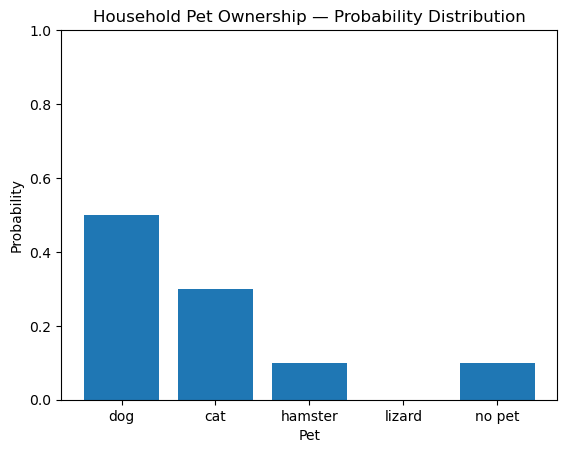

In [104]:
plt.figure()
plt.bar(pet_labels, pet_values)

plt.title("Household Pet Ownership — Probability Distribution")
plt.xlabel("Pet")
plt.ylabel("Probability")
plt.ylim(0, 1)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'owns_laptop'),
  Text(1, 0, 'took_coding_course'),
  Text(2, 0, 'has_part_time_job'),
  Text(3, 0, 'uses_public_transit'),
  Text(4, 0, 'exercises_regularly')])

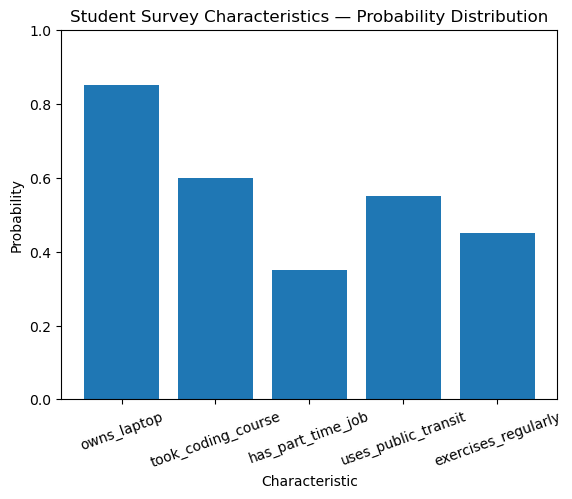

In [105]:
# --- Student Characteristics Distribution ---
student_labels = list(student_probs.keys())
student_values = list(student_probs.values())

plt.figure()
plt.bar(student_labels, student_values)

plt.title("Student Survey Characteristics — Probability Distribution")
plt.xlabel("Characteristic")
plt.ylabel("Probability")
plt.ylim(0, 1)
plt.xticks(rotation=20)


## 5. Law of Large Numbers

The **Law of Large Numbers** states that as you repeat a random experiment more and more times, the observed average result will get closer and closer to the true theoretical probability.

In other words — the more trials you run, the more your results will reflect reality.

> Example: Flip a fair coin 10 times and you might get 7 Heads. Flip it 10,000 times and the proportion of Heads will be very close to 0.5.

This is why probability works in practice. Individual outcomes are unpredictable, but patterns emerge reliably over a large number of trials.


In [106]:
def calc_prob_of_heads(flips):
    total_heads = 0

    for flip in range(flips):
        result = random.choice([0, 1])
        if result == 1:
            total_heads = total_heads + 1

    probability_of_heads = total_heads / flips
    return probability_of_heads

In [107]:
flips = 100
prob = calc_prob_of_heads(flips)
print("Probability of heads after", flips, "flips:", prob)

Probability of heads after 100 flips: 0.49


In [108]:
flip_counts  = [10, 50, 100, 200, 300, 500, 700, 800, 1000, 1500, 3000, 4000, 5000, 10000, 50000]
probabilities = []

for count in flip_counts:
    prob = calc_prob_of_heads(count)
    probabilities.append(prob)

theoretical = [0.5] * len(flip_counts)
print(theoretical)

[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]


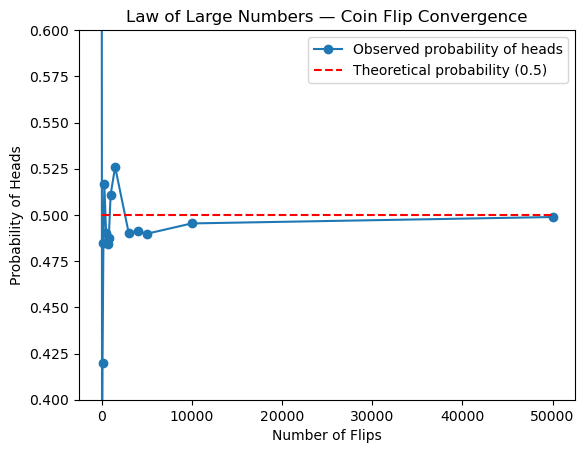

In [109]:
plt.figure()

plt.plot(flip_counts, probabilities, marker="o", label="Observed probability of heads")
plt.plot(flip_counts, theoretical, linestyle="--", color="red", label="Theoretical probability (0.5)")

plt.title("Law of Large Numbers — Coin Flip Convergence")
plt.xlabel("Number of Flips")
plt.ylabel("Probability of Heads")

plt.ylim(0.4, 0.6)
plt.legend()

## 6. Bayesian Statistics

**Bayesian statistics** is an alternative framework for thinking about probability. Where frequentist statistics treats probability as a fixed fact about the world, Bayesian statistics treats probability as a **degree of belief** — something that starts as an educated guess and gets updated as new evidence comes in.

---

### Frequentist View — Pros and Cons

| | |
|---|---|
| **Pro** | Objective and reproducible — results do not depend on prior beliefs |
| **Pro** | Simple to apply when you have a lot of data |
| **Con** | Cannot incorporate existing knowledge — every analysis starts from scratch |
| **Con** | Can give misleading results with small sample sizes |
| **Con** | Cannot make probability statements about a hypothesis — only about the data |

---

### Bayesian View — Benefits

- **Incorporates prior knowledge.** If you already have relevant information before collecting data, Bayesian statistics lets you use it rather than discard it.
- **Updates naturally.** As new data arrives, your belief is revised. You never have to start over — you just update.
- **Works well with small samples.** Prior knowledge compensates for limited data, making it practical in fields like medicine where large trials are expensive.
- **Answers the question you actually care about.** Bayesian statistics lets you say "there is a 92% chance this treatment works" — a direct probability statement about the hypothesis itself.

---

### Conditional Probability and Bayes' Theorem

The foundation of Bayesian statistics is **conditional probability** — the probability of event A occurring *given that* event B has already occurred.

$$P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}$$

| Term | Name | Meaning |
|---|---|---|
| $P(A \mid B)$ | **Posterior** | Updated probability of A after observing B |
| $P(A)$ | **Prior** | Initial belief about A before seeing any data |
| $P(B \mid A)$ | **Likelihood** | Probability of observing B if A were true |
| $P(B)$ | **Evidence** | Overall probability of observing B under any circumstance |

---

### Example

Suppose a medical test for a disease is 99% accurate. The disease affects 1% of the population.

- $P(\text{disease}) = 0.01$ — prior: 1 in 100 people have it
- $P(\text{positive} \mid \text{disease}) = 0.99$ — likelihood: the test catches it 99% of the time
- $P(\text{positive}) = 0.0198$ — evidence: overall rate of positive tests in the population

$$P(\text{disease} \mid \text{positive}) = \frac{0.99 \times 0.01}{0.0198} \approx 0.50$$

Even with a positive test result, there is only about a **50% chance** the patient actually has the disease. This is because the disease is rare — the prior matters enormously.


In [110]:
# --- Bayes' Theorem: COVID Test Example ---
#
# A person takes a COVID test and receives a POSITIVE result.
# The test has 90% reliability (sensitivity).
# What is the true probability they actually have COVID?
#
# P(covid | positive) = (P(positive | covid) * P(covid)) / P(positive)

# Prior: estimated share of the population currently infected
p_covid    = 0.012   # 1.2% base rate — the percent of population in NY with Covid
p_no_covid = 1 - p_covid

In [111]:
# Likelihood: how well the test performs
p_positive_given_covid    = 0.90   # true positive rate  — test catches 90% of real cases
p_positive_given_no_covid = 0.1   # false positive rate — test wrongly flags 10% of healthy people

In [112]:
# Evidence: overall probability of testing positive (regardless of true status)
p_positive = (p_positive_given_covid * p_covid) + (p_positive_given_no_covid * p_no_covid)
print("Probability of testing positive given all these measures", p_positive)

Probability of testing positive given all these measures 0.1096


In [113]:
# Posterior: updated probability of having COVID given a positive test result
p_covid_given_positive = (p_positive_given_covid * p_covid) / p_positive

print("Probability of having covid given we test positive", p_covid_given_positive)

Probability of having covid given we test positive 0.09854014598540146


In [114]:
# --- Bayesian Update: Second Test Comes Back NEGATIVE ---
#
# We use the posterior from the first test as our new prior.
# The same test is administered again and returns a POSITIVE result.
# What is the updated probability of having COVID now?

# New prior — our updated belief after the first positive test
p_covid_prior_2    = p_covid_given_positive
p_no_covid_prior_2 = 1 - p_covid_prior_2

print("Our new prior", p_covid_prior_2)
print("Our new negation of the prior", p_no_covid_prior_2)

Our new prior 0.09854014598540146
Our new negation of the prior 0.9014598540145985


In [115]:
# Likelihood: how well the test performs
# we are still testing the probability of a positive 
p_positive_given_covid    = 0.90   # true positive rate  — test catches 90% of real cases
p_positive_given_no_covid = 0.1   # false positive rate — test wrongly flags 10% of healthy people

In [116]:
# Evidence: overall probability of testing negative
p_positive = (p_positive_given_covid * p_covid_prior_2) + (p_positive_given_no_covid * p_no_covid_prior_2)

# Posterior: updated probability of having COVID given a negative second test
p_covid_given_positive_2 = (p_positive_given_covid * p_covid_prior_2) / p_positive

print("Probability of having covid given we test positive a second time", p_covid_given_positive_2)

Probability of having covid given we test positive a second time 0.49591836734693884


---

## Exercises

For each question below, **work out the answer by hand first**, then write Python code in a new cell to validate your result.

---

### Exercise 1 — Elementary Events

A bag contains **3 red marbles, 5 blue marbles, and 2 green marbles** (10 total).

You reach in and draw one marble at random.

- **A.** What is the probability of drawing a red marble?
- **B.** What is the probability of drawing a green marble?
- **C.** What is the probability of drawing a yellow marble?

> **Hint:** P(event) = number of favorable outcomes / total number of outcomes

In [117]:
bag = {
    "red": 3,
    "blue": 5,
    "green": 2
}

...


Ellipsis

---

### Exercise 2 — Non-Elementary Events (Mutually Exclusive)

A single fair die is rolled once. Assume each face is mutually exclusive.

- **A.** What is the probability of rolling a number greater than 4?
- **B.** What is the probability of *not* rolling a 1?
- **C.** What is the probability of rolling a 2 **or** a 5?

> **Hint:** For mutually exclusive events, P(A or B) = P(A) + P(B)

In [118]:
dice_roll = [1, 2, 3, 4, 5, 6]

...

Ellipsis

---

### Exercise 3 — Non-Elementary Events (Non-Mutually Exclusive)

A survey finds that among a group of students:
- **60%** own a bike
- **45%** own a skateboard
- **25%** own both

- **A.** What is the probability a student owns a bike **or** a skateboard?
- **B.** What is the probability a student owns **neither**?
- **C.** What is the probability a student owns a bike but **not** a skateboard?

> **Hint:** P(A or B) = P(A) + P(B) - P(A and B)

In [119]:
ownership = {
    "bike": 0.6,
    "skateboard": 0.45,
    "both": 0.25
}

...

Ellipsis

---

### Exercise 4 — Bayesian Probability

A factory produces widgets. **2%** of all widgets are defective. A quality control scanner is used to flag defective widgets. The scanner correctly identifies a defective widget **85%** of the time, and incorrectly flags a non-defective widget **4%** of the time.

A widget is scanned and the result comes back **flagged**.

- **A.** What is the prior probability the widget is defective?
- **B.** Calculate the evidence — the overall probability of a widget being flagged.
- **C.** Use Bayes' theorem to find the probability the widget is truly defective given that it was flagged.
- **D.** Does the result surprise you? Why might a high-accuracy scanner still produce many false alarms?

> **Hint:** P(defective | flagged) = P(flagged | defective) × P(defective) / P(flagged)
